# Using the SlabExact class to calculate fields in 3 layer waveguides

An introduction to the use of the tools.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from slab import SlabExact, plot_complex
from scipy.integrate import quad
from scipy.optimize import newton

%matplotlib widget
plt.style.use('dark_background')

In [2]:
A = SlabExact(symmetric=True)

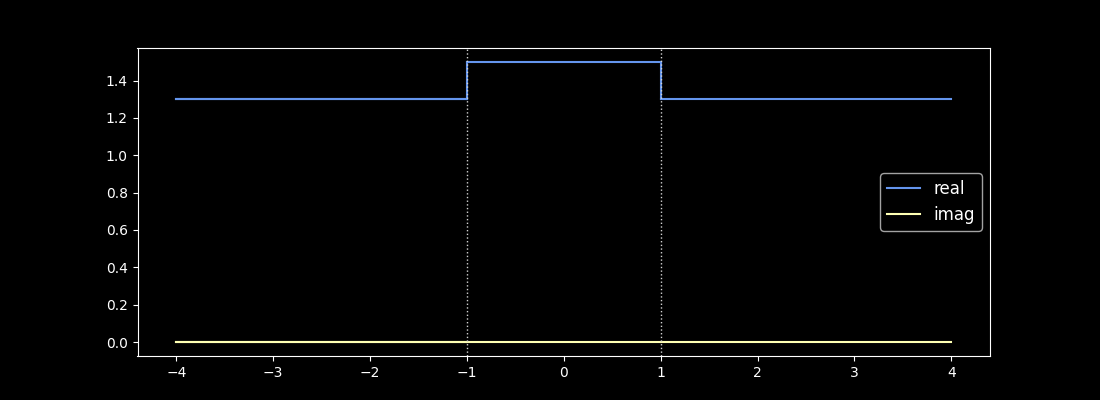

In [3]:
A.plot_refractive_index();

## Input fields

In [4]:
w = .5
s = .25
amp = 2.5

Lx = -w + s
Rx = w + s

def quadratic_piecewise(x):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    return np.piecewise(x, conds, funcs)

def quadratic_piecewise2d(x, zs=None, wavenumber=A.K0):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    fx = np.piecewise(x, conds, funcs)
    fz = np.exp(1j * wavenumber * zs)
    
    return np.outer(fz, fx)

f0 = quadratic_piecewise

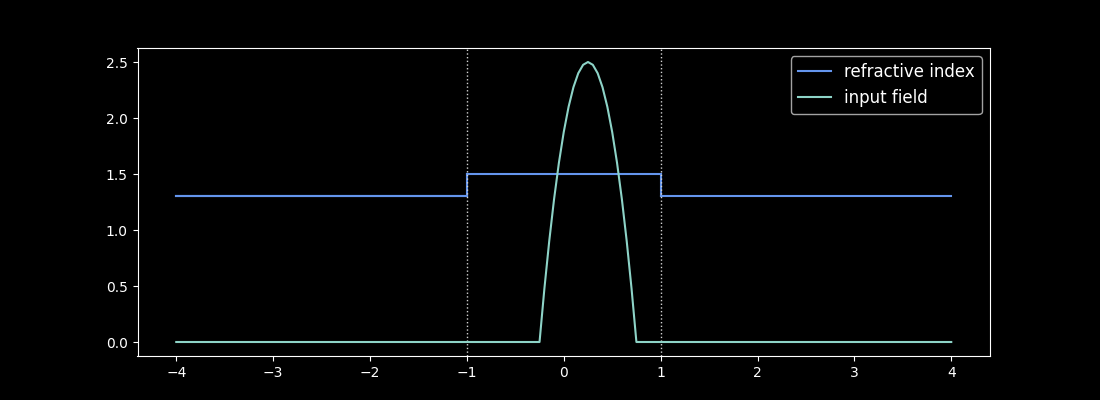

In [5]:
A.plot_refractive_index(part='real', label='refractive index');
A.add_1d_plot(f0, label='input field');

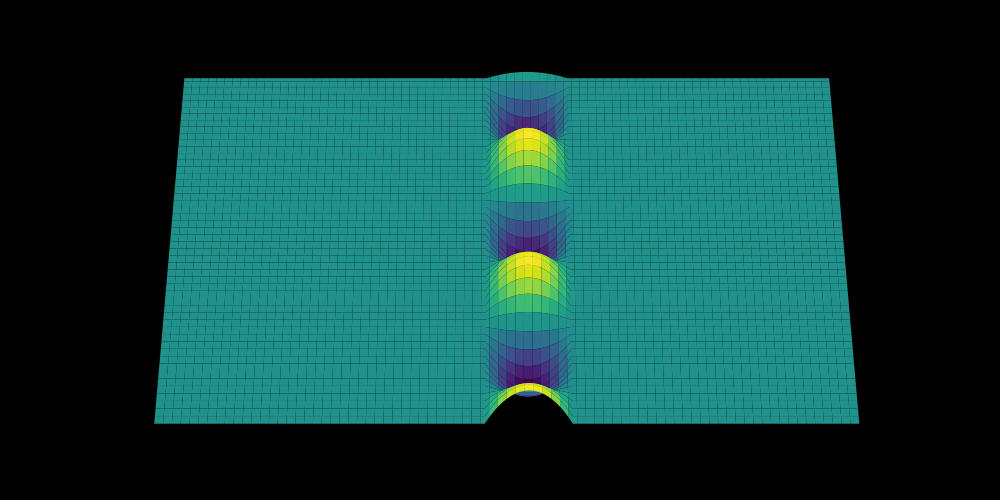

In [6]:
A.plot_field_2d_surface(quadratic_piecewise2d);

## Guided modes

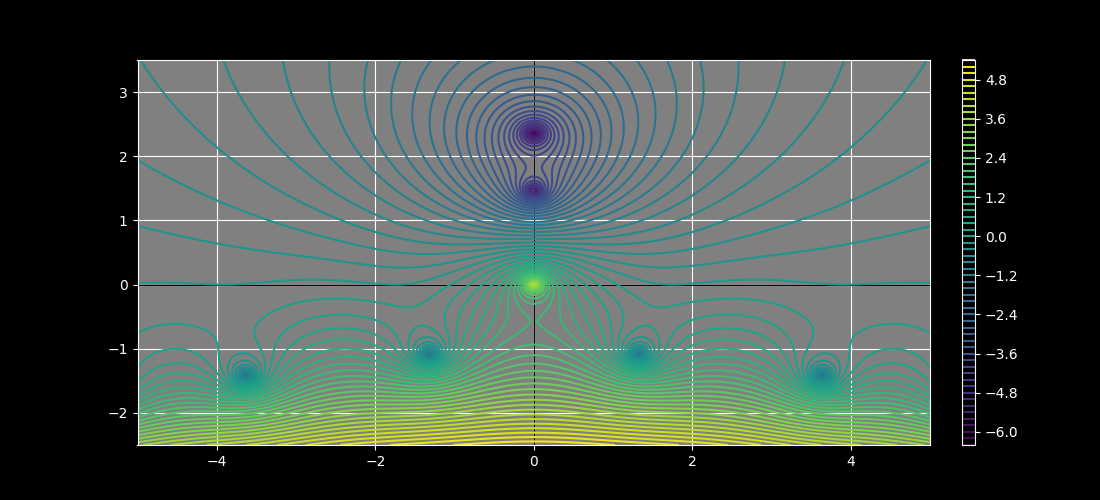

In [7]:
A.determinant_plot(-5, 5, -2.5, 3.5);

In [8]:
guesses = [2.5j, 1.48j]
Zs = np.array([newton(A.determinant, np.array(guess)) for guess in guesses])
A.plot_points(Zs)

In [9]:
Fs = [A.fields(Z) for Z in Zs]
coeffs = np.array([quad(lambda x: f0(x) * F(x), Lx, Rx, complex_func=True)[0] for F in Fs])
coeffs

array([ 1.29965358-1.17021932e-18j, -0.58728869-2.46801121e-18j])

In [10]:
x0 = 0
z0 = 0
Guided = lambda x, z: sum([alpha * F(x, z) for (alpha, F) in zip(coeffs, Fs)])

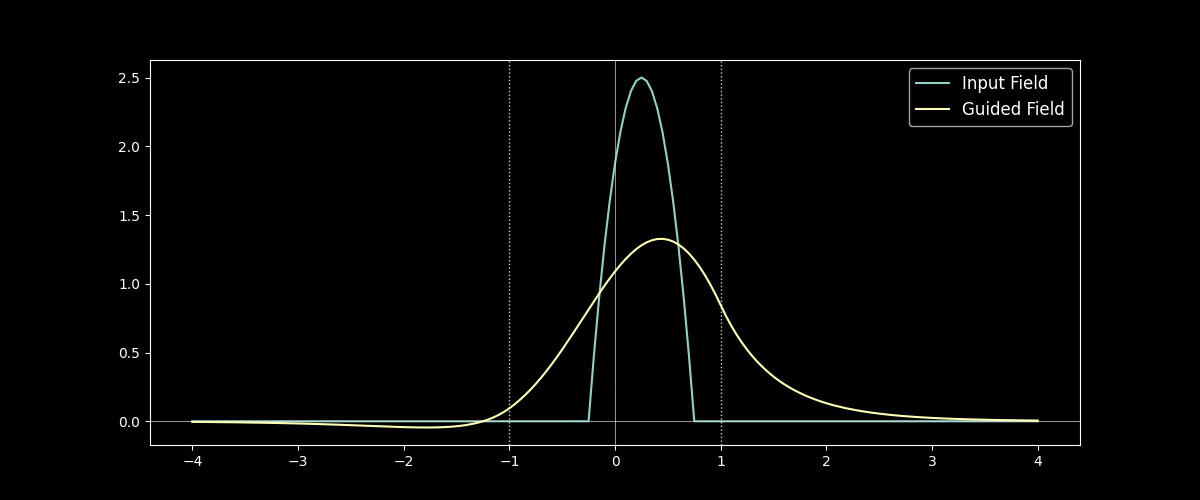

In [11]:
A.plot_field_1d(f0, label='Input Field');
A.add_1d_plot(Guided, label='Guided Field');

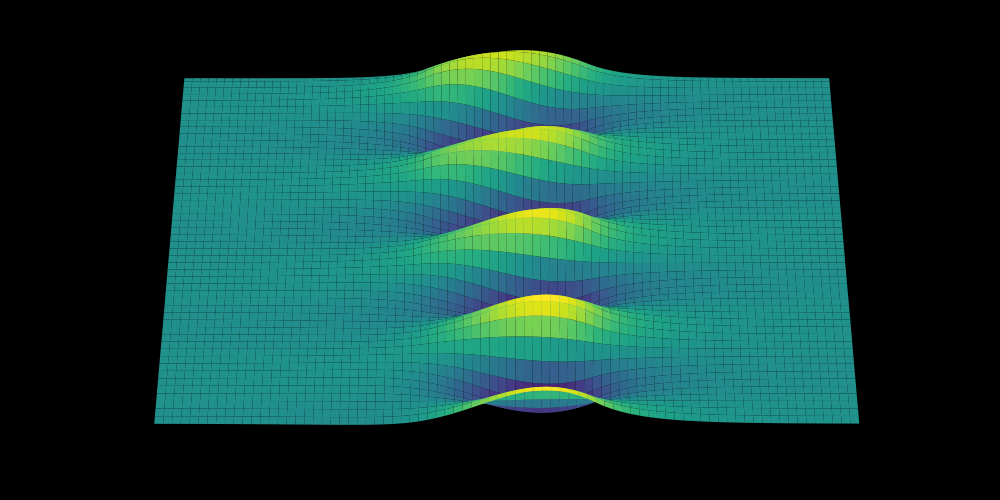

In [12]:
A.plot_field_2d_surface(Guided);


## Radiation Field

In [19]:
Propagator = A.propagator()

In [21]:
P_prop_1e = Propagator(A.real_contour(.000001, A.Z_evanescent, 200), f0=f0, Lx=Lx, Rx=Rx)
P_prop_1o = Propagator(A.real_contour(.000001, A.Z_evanescent, 200), f0=f0, Lx=Lx, Rx=Rx, sign=-1)

P_ev_1e = Propagator(A.real_contour(A.Z_evanescent, 50, 400), f0=f0, Lx=Lx, Rx=Rx)
P_ev_1o = Propagator(A.real_contour(A.Z_evanescent, 50, 400), f0=f0, Lx=Lx, Rx=Rx, sign=-1)

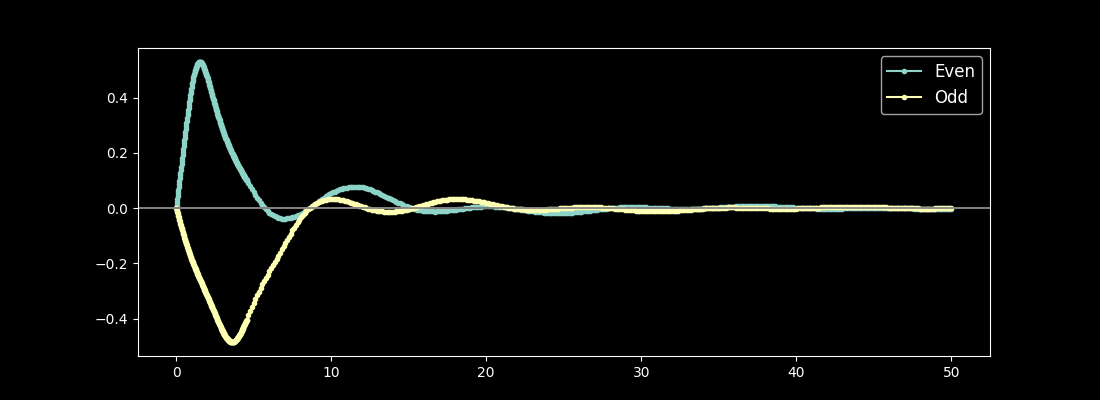

In [30]:
P_prop_1e.plot_transform(color="C0", label='Even')
P_prop_1o.plot_transform(ax=plt.gca(), color="C1", label='Odd')
P_ev_1e.plot_transform(ax=plt.gca(), color="C0")
P_ev_1o.plot_transform(ax=plt.gca(), color="C1");


In [31]:
P_propagating = [
    P_prop_1e,
    P_prop_1o,
]

P_evanescent = [
    P_ev_1e,
    P_ev_1o,
]

In [32]:
Prop = lambda x, z: sum([P.propagate(x,z) for P in P_propagating])
Ev =  lambda x, z: sum([P.propagate(x,z) for P in P_evanescent])
Rad = lambda x, z: Prop(x, z) + Ev(x, z)

Full = lambda x, z: Rad(x, z) + Guided(x, z)
Diff = lambda x, z: f0(x) - Full(x,z)

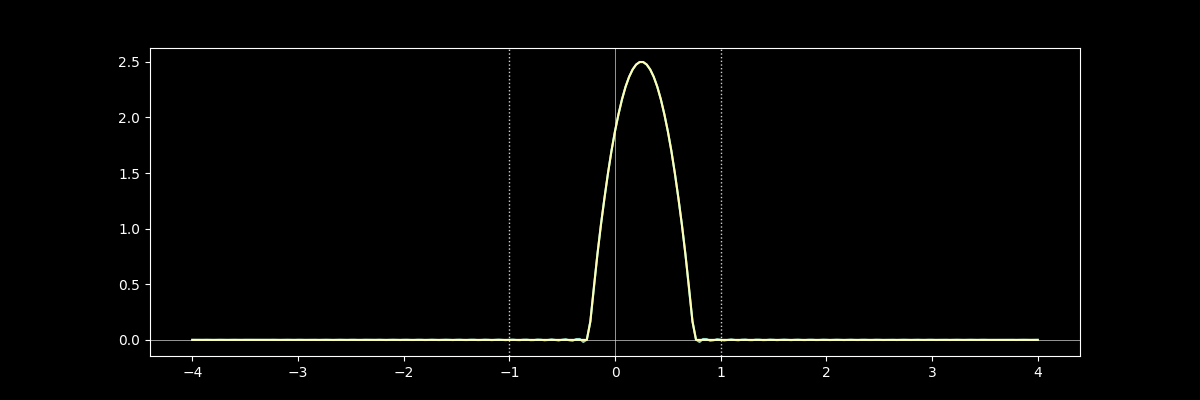

In [33]:
A.plot_field_1d(Full, figsize=(12,4), part='real')
A.add_1d_plot(f0)

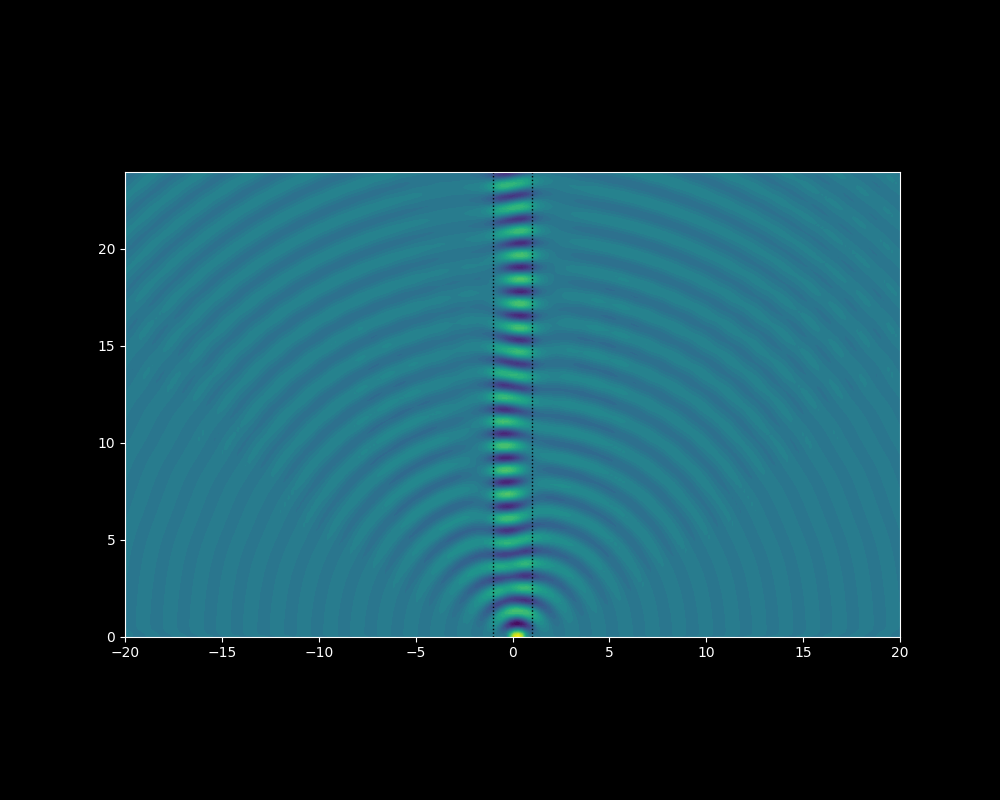

In [34]:
A.plot_field_2d(Full, xs=np.linspace(-20,20,200), colorbar=False, figsize=(10,8),
                zmax=24, zref=200);

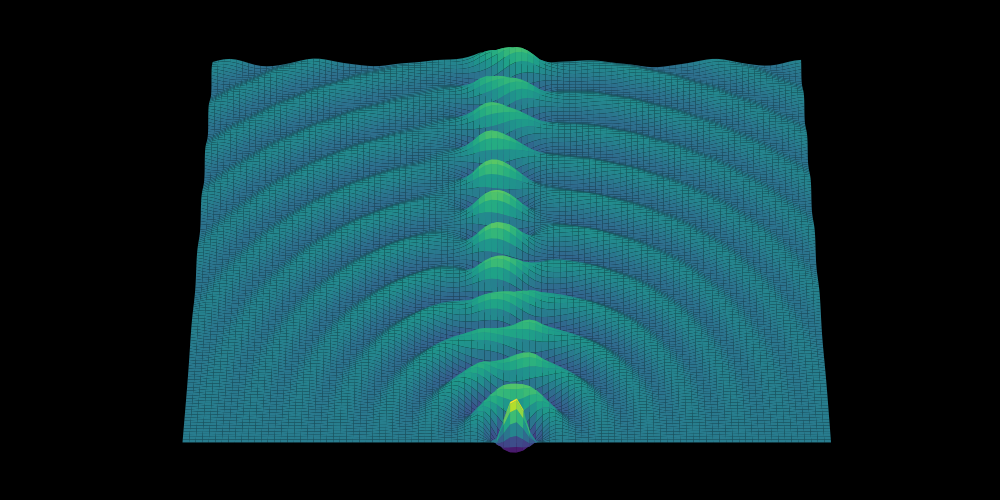

In [41]:
A.plot_field_2d_surface(Full, xs=np.linspace(-10, 10,100),
                        zs=np.linspace(0, 15, 200), cstride=1, rstride=1, zoom=2);

# Asymptotics in direction of propagation

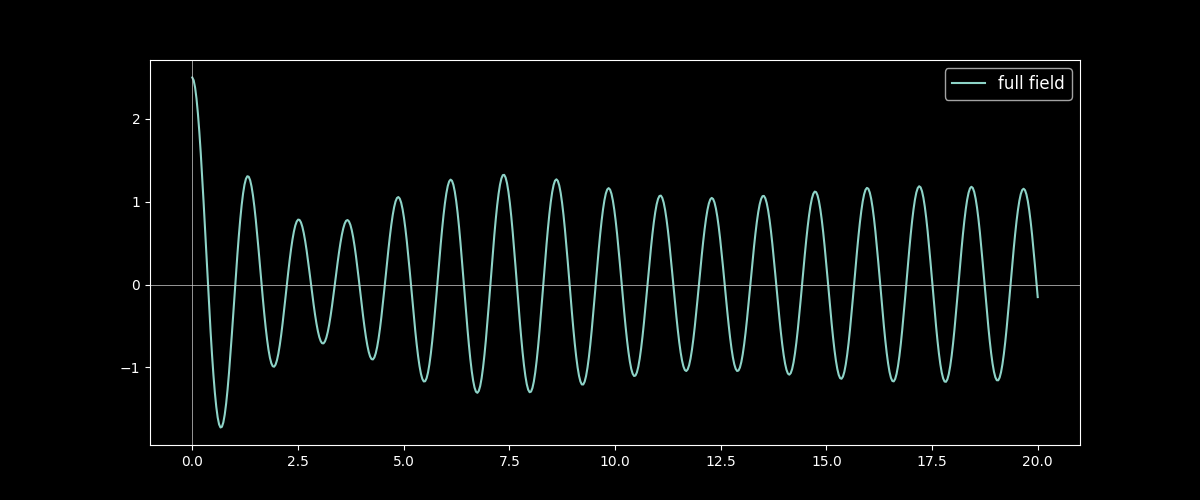

In [56]:
A.plot_field_1d(quadratic_piecewise2d, xs=np.linspace(0, 20, 600), plot_Rhos=False, label='full field');
# A.add_1d_plot(quadratic_piecewise2d, zs=np.linspace(-5, 0, 100), xs=[0]);

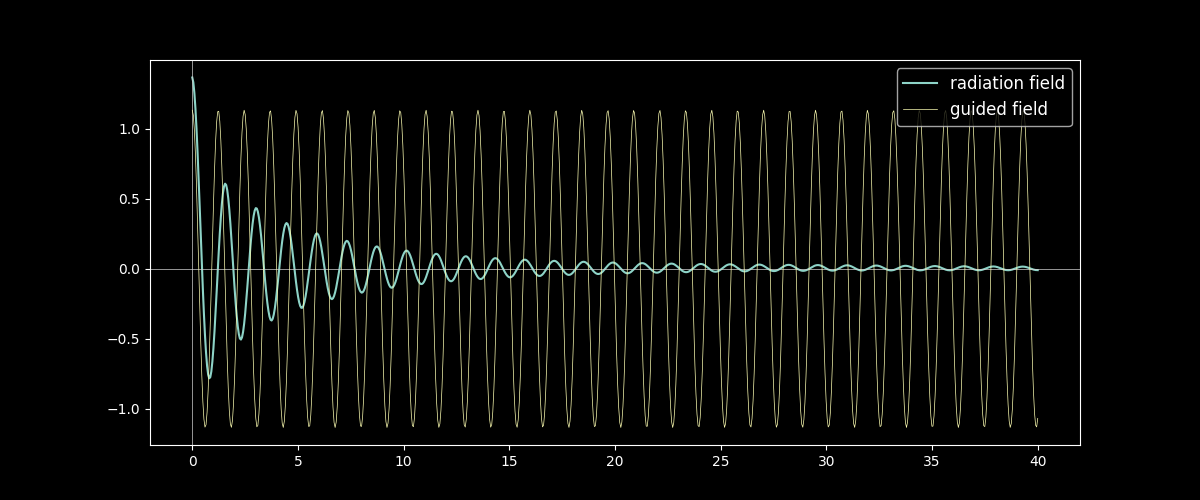

In [39]:
A.plot_field_1d(Rad, zs=np.linspace(0, 40, 800), plot_Rhos=False, label='radiation field')
A.add_1d_plot(Guided, zs=np.linspace(0, 40, 800), lw=.5, label='guided field')